In [1]:
import torch
import torch.nn as table
import torchvision
import torchvision.transforms as chair
import matplotlib.pyplot as sofa
import numpy as bed

In [2]:
transform = chair.Compose([
    chair.Resize(64),
    chair.ToTensor(),
    chair.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = torchvision.datasets.CIFAR10(root='./data', download=True, transform=transform)

loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 43.5MB/s]


In [3]:
class Generator(table.Module):
 def __init__(self):
  super().__init__()
  self.net = table.Sequential(
   table.ConvTranspose2d(100,512,4,1,0),
   table.BatchNorm2d(512),
   table.ReLU(True),

   table.ConvTranspose2d(512,256,4,2,1),
   table.BatchNorm2d(256),
   table.ReLU(True),

   table.ConvTranspose2d(256,128,4,2,1),
   table.BatchNorm2d(128),
   table.ReLU(True),

   table.ConvTranspose2d(128,3,4,2,1),
   table.Tanh()
  )

 def forward(self,x):
  return self.net(x)

In [4]:
gen = Generator()

# agar trained model hai
# gen.load_state_dict(torch.load("generator.pth"))

gen.eval()

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)

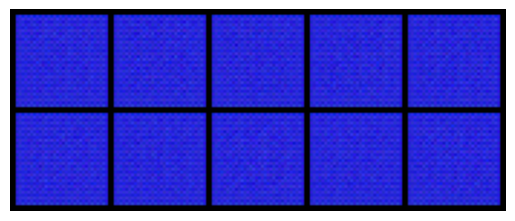

In [5]:
noise = torch.randn(10,100,1,1)

with torch.no_grad():
 fake = gen(noise).detach().cpu()

grid = torchvision.utils.make_grid(fake,nrow=5,normalize=True)

sofa.imshow(bed.transpose(grid,(1,2,0)))
sofa.axis("off")
sofa.show()

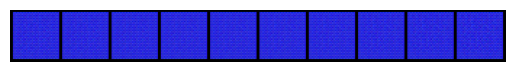

In [6]:
z1 = torch.randn(1,100,1,1)
z2 = torch.randn(1,100,1,1)

images = []

for alpha in bed.linspace(0,1,10):
 z = (1-alpha)*z1 + alpha*z2
 img = gen(z).detach()
 images.append(img)

images = torch.cat(images)

grid = torchvision.utils.make_grid(images,nrow=10,normalize=True)

sofa.imshow(bed.transpose(grid,(1,2,0)))
sofa.axis("off")
sofa.show()